# MerLin Release 0.4 Highlights

MerLin 0.4 introduces exciting new features to make your experience even more complete:

- You can now use NoiseModel (to model indistinguishability, g2, transmittance, brightness, phase error and phase imprecision noises) and differentiate it so you can train better hardware-informed model for better inference on QPU!
- You can use built-in models in MerLin: a photonic QGAN, a Reservoir classifier, a QCNN so you can easily manipulate state-of-the-art quantum models.
- Memristive phase shifters are now usable as a simple method of the ``CircuitBuilder``.
- Also, a new ``EncodingSpace`` object is introduced to easily encode logical state vectors in the full Fock basis.

This notebook is a quick overview of these new features and it identifies the deprecations and breaking changes of MerLin v.0.4.x

## 0. Imports

In [1]:
import torch

import matplotlib.pyplot as plt
import merlin as ml
import numpy as np
import perceval as pcvl

from merlin.core import StateVector
from merlin.datasets import mnist_digits
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

## 1. New Features

Here is a brief overview of the main new features.

### 1.1 ``ReservoirClassifier``

ReservoirClassifier is the new ready-to-use QORC model. It builds a frozen photonic reservoir from a Haar-random interferometer and trains only a classical linear readout.

This makes the QORC workflow available as a reusable model instead of requiring users to manually wire preprocessing, reservoir feature extraction, caching, and readout training. The model supports optional scikit-learn dimensionality reduction, reservoir feature normalization, cached embeddings, and direct creation of PyTorch datasets for the readout.

For more details, check out the [ReservoirClassifier documentation](../../user_guide/models/reservoir_classifier.rst).

The basic workflow of this new object will be presented as we try to classify the MNIST. Since this dataset contains images that are 28x28, we need to reduce the feature dimension (``in_features``) since it is too big for current interferometers. We will use the ``reduction`` parameter of the ``ReservoirClassifier`` classifier to do so. Indeed, we will use the PCA reduction (available in the ``sklearn`` library) to reduce the images to its 12 most important features.

In [2]:
# 0. Get the data
train_features, train_labels, train_metadata = mnist_digits.get_data_train_original()
test_features, test_labels, test_metadata = mnist_digits.get_data_test_original()

#As vector
train_features = train_features.reshape(train_features.shape[0], -1)
test_features = test_features.reshape(test_features.shape[0], -1)

# 1. Create the reservoir classifier
reservoir_classifier=ml.ReservoirClassifier(
    in_features=train_features.shape[1],
    out_features=10,
    n_photons=2,
    reduction=PCA(
        n_components=12,
        svd_solver="randomized",
       ),
    )

# 2. Call fit reservoir on the training inputs
reservoir_classifier.fit_reservoir(train_features)

# 3. Generate the reservoir embeddings
train_embeddings = reservoir_classifier.transform_reservoir(train_features)
test_embeddings = reservoir_classifier.transform_reservoir(test_features)
## make_dataset(X, y) can also be used to return a TensorDataset instead
# of a simple tensor

## If you want the output logits of the reservoir,call predict(X)

# 4. Train the readout layer
readout = torch.nn.Linear(
    train_embeddings.shape[1],
    10,
)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(readout.parameters(), lr=0.01)

for epoch in range(20):
    optimizer.zero_grad()

    logits = readout(train_embeddings)
    loss = criterion(logits, torch.tensor(train_labels))

    loss.backward()
    optimizer.step()

    with torch.no_grad():
        logits = readout(test_embeddings)
        predictions = logits.argmax(dim=1)

    print(f"Epoch {epoch+1}: loss={loss.item():.4f} and test accuracy of {(predictions == test_labels).float().mean().item():.4f}")


# 5. Evaluate the model
with torch.no_grad():
    logits = readout(test_embeddings)
    predictions = logits.argmax(dim=1)

accuracy = (predictions == test_labels).float().mean().item()

print(f"Test accuracy: {accuracy:.4f}")

Epoch 1: loss=2.5237 and test accuracy of 0.2859
Epoch 2: loss=2.1271 and test accuracy of 0.4185
Epoch 3: loss=1.8060 and test accuracy of 0.5375
Epoch 4: loss=1.5558 and test accuracy of 0.6138
Epoch 5: loss=1.3669 and test accuracy of 0.6508
Epoch 6: loss=1.2268 and test accuracy of 0.6738
Epoch 7: loss=1.1229 and test accuracy of 0.6882
Epoch 8: loss=1.0450 and test accuracy of 0.7047
Epoch 9: loss=0.9854 and test accuracy of 0.7148
Epoch 10: loss=0.9389 and test accuracy of 0.7231
Epoch 11: loss=0.9017 and test accuracy of 0.7324
Epoch 12: loss=0.8711 and test accuracy of 0.7392
Epoch 13: loss=0.8452 and test accuracy of 0.7430
Epoch 14: loss=0.8227 and test accuracy of 0.7498
Epoch 15: loss=0.8025 and test accuracy of 0.7561
Epoch 16: loss=0.7843 and test accuracy of 0.7624
Epoch 17: loss=0.7676 and test accuracy of 0.7674
Epoch 18: loss=0.7525 and test accuracy of 0.7726
Epoch 19: loss=0.7389 and test accuracy of 0.7781
Epoch 20: loss=0.7268 and test accuracy of 0.7823
Test accu

/var/folders/k_/9bm2xqh95599gcr_s25f45740000gn/T/ipykernel_35913/2286803118.py:53: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  print(f"Epoch {epoch+1}: loss={loss.item():.4f} and test accuracy of {(predictions == test_labels).float().mean().item():.4f}")


### 1.2 ``PhotonicGenerator``

`PhotonicGenerator` is a PyTorch module for latent-to-sample generative workflows. It wraps one or more `QuantumLayer` heads and delegates the final
classical interpretation to an output adapter.

This provides a cleaner base for photonic GAN-style generators. Instead of manually feeding latent variables into a quantum layer and reshaping raw measurement distributions for each experiment, users can define a generator with a latent dimension, one or more quantum heads, and an adapter such as `ImageAdapter` or `VectorAdapter`.

The generator exposes `sample_latent`, `measure`, `generate`, and normal PyTorch `forward` behavior.

In practice, this generator is used as part of a QGAN. In this model, a classical discriminator is also used to train the `PhotonicGenerator`: both are trained at the same time. To see the complete pipeline, please consult [this notebook](../../notebooks/reproduced_papers/photonic_QGAN.ipynb). It is based on the original photonic QGAN paper that was reproduced with MerLin.

For more details on the `PhotonicGenerator` and the QGAN model, check out the [QGAN documentation](../../user_guide/models/qgan.rst).

Below is some examples on how to instantiate a `PhotonicGenerator`.

In [ ]:
# Define the basic interferometer
circuit = ml.CircuitBuilder(n_modes=3)
circuit.add_entangling_layer()
circuit.add_angle_encoding([0, 1])
circuit.add_entangling_layer()

qlayer = ml.QuantumLayer(
    input_size=2,
    builder=circuit,
    n_photons=1,
    measurement_strategy=ml.MeasurementStrategy.probs(
        computation_space=ml.ComputationSpace.FOCK,
    ),
)


#Option 1: Same quantum layer repeated for each generator head
generator = ml.PhotonicGenerator(
    layers=qlayer,
    count=2,    #Number of generator heads
    # Adapter of the output of the layer to the desired data format. 
    # Here it takes the layers' ouput and transforms it to an image
    output_adapter=ml.ImageAdapter(     
        shape=(1, 32, 32),  #Shape of one image
        headwise=True,
        normalize_patches=True,
    ),
)
print(generator)

#Option 2: Sequence of layers, each a generator head
# Define the basic interferometer
circuit = ml.CircuitBuilder(n_modes=3)
circuit.add_entangling_layer()
circuit.add_angle_encoding([0, 1])
circuit.add_entangling_layer()

qlayer_2 = ml.QuantumLayer(
    input_size=2,
    builder=circuit,
    n_photons=1,
    measurement_strategy=ml.MeasurementStrategy.probs(
        computation_space=ml.ComputationSpace.FOCK,
    ),
)


generator = ml.PhotonicGenerator(
    layers=[qlayer,qlayer_2], #Sequence of layers each being a generator
    # Adapter of the output of the layer to the desired data format. 
    # Here it takes the layers' ouput and transforms it to a vector f the correct size
    output_adapter=ml.VectorAdapter(
        size=32 #Desired size
    ),
)
print(generator)

PhotonicGenerator(
  (layers): ModuleList(
    (0-1): 2 x QuantumLayer(
      (_photon_loss_transform): PhotonLossTransform()
      (_detector_transform): DetectorTransform()
      (measurement_mapping): Probabilities()
    )
  )
  (output_adapter): ImageAdapter(
    (_vector_adapter): VectorAdapter()
  )
)
PhotonicGenerator(
  (layers): ModuleList(
    (0-1): 2 x QuantumLayer(
      (_photon_loss_transform): PhotonLossTransform()
      (_detector_transform): DetectorTransform()
      (measurement_mapping): Probabilities()
    )
  )
  (output_adapter): VectorAdapter()
)


### 1.3 ``QCNNClassifier``

`QCNNClassifier` adds a staged photonic QCNN model for image-like inputs. Architectures are built from validated `QConv`, `QPool`, and `QDense` stages. Users can provide their own stage sequence or rely on the default validated architecture.

This gives users a higher-level image-classification model without requiring them to assemble every quantum convolution, pooling step, and dense readout by
hand.

For more details, check out the [QCNN documentation](../../user_guide/models/qcnn.rst).

Below is an example on how to instantiate a default `QCNNClassifier` and then use it to classify a simple dataset of images 8x8 images of hand-drawn zeros or ones. We will use the default `QCNNClassifier`.

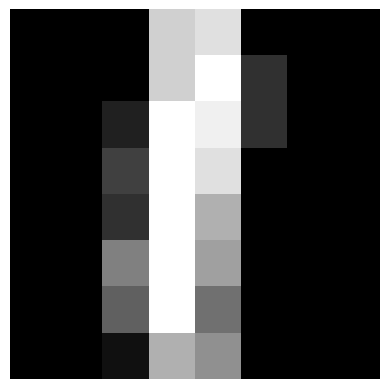

With label: 1


In [4]:
# 0. Get the data
mnist_x, mnist_y = load_digits(return_X_y=True)

# Keep only selected classes
mask = np.isin(mnist_y, [0,1])
mnist_x = mnist_x[mask]
mnist_y = mnist_y[mask]

# Train/test split
train_features, test_features, train_labels, test_labels = train_test_split(
    mnist_x, mnist_y, test_size=200,
)# Since there are only 360 data points in this specific dataset with labels = 0 or 1, that implies that we will have 160 training points.

#transform to tensors
train_features=torch.tensor(train_features)
test_features=torch.tensor(test_features)
train_labels=torch.tensor(train_labels)
test_labels=torch.tensor(test_labels)

# Reshape to 8×8 images
train_features = train_features.reshape(-1,1, 8, 8)
test_features = test_features.reshape(-1,1, 8, 8)


plt.imshow(train_features[0][0], cmap="gray")
plt.axis("off")  # hide axes
plt.show()
print(f"With label: {train_labels[0]}")

In [26]:
# 1. Create the QCNN model
qcnn = ml.QCNNClassifier(
    input_shape=(8,8),   #Shape of the input
    num_classes=2,  #Number of classes
    #Stages in QCNN classifier, this is the default values when stages=None
    stages= [
        ml.QCNNClassifier.QConv(kernel_size=2, stride=2),
        ml.QCNNClassifier.QPool(kernel_size=2),
        ml.QCNNClassifier.QDense()
        ],
    )

# 2. Train the model just like any other Pytorch module
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(qcnn.parameters(), lr=0.01)

for epoch in range(40):
    optimizer.zero_grad()

    logits = qcnn(train_features)
    loss = criterion(logits, train_labels)

    loss.backward()
    optimizer.step()

    with torch.no_grad():
        logits = qcnn(test_features)
        predictions = logits.argmax(dim=1)
    if (epoch+1)%5==0:
        print(f"Epoch {epoch+1}: loss={loss.item():.4f} and test accuracy of {(predictions == test_labels).float().mean().item():.4f}")

# 3. Evaluate the model
with torch.no_grad():
    logits = qcnn(test_features)
    predictions = logits.argmax(dim=1)

accuracy = (predictions == test_labels).float().mean().item()

print(f"Test accuracy: {accuracy:.4f}")


Epoch 5: loss=0.6913 and test accuracy of 0.5100
Epoch 10: loss=0.6844 and test accuracy of 0.5150
Epoch 15: loss=0.6768 and test accuracy of 0.6600
Epoch 20: loss=0.6682 and test accuracy of 0.9450
Epoch 25: loss=0.6593 and test accuracy of 0.9450
Epoch 30: loss=0.6497 and test accuracy of 0.9550
Epoch 35: loss=0.6392 and test accuracy of 0.9400
Epoch 40: loss=0.6280 and test accuracy of 0.9200
Test accuracy: 0.9200


### 1.4 Memristive Phase Shifters

`CircuitBuilder` now supports memristive phase shifters through
`add_memristive_ps(...)`.

For machine-learning workflows, this gives a photonic layer a stateful
component that can carry information across repeated calls or timesteps. That is useful for temporal dependence, recurrent-style models, feedback circuits, and sequence experiments where the current circuit response should depend on previous inputs rather than only on the current tensor.

The builder declares the memristive component, and `QuantumLayer` owns the runtime state, history, serialization hooks, reset behavior, and
`detach_memristive_state(...)` helper. This moves a previously manual feedback layer pattern into the normal builder-layer contract.

For more information on the use of the memristive phase shifters, please consult the corresponding section in [QuantumLayer's documentation](../../api_reference/api/merlin.algorithms.layer.rst).

Here is a quick example on how to use a memristive phase shifter.

In [6]:
# 1. Define the update rule that the phase shifter will follow. 
# It must have this signature but output may be a typed object
# since it is directly the return of the QuantumLayer.
def update_rule_exp(state: torch.Tensor, output: torch.Tensor):
    return torch.exp(state + output[:, 0])

#2. Create the layer with the circuit builder
circ = ml.CircuitBuilder(n_modes=3)
circ.add_entangling_layer()
# Add a memristive phase shifter
circ.add_memristive_ps(
    mode=0, #The mode onto which the memristive phase shifter must be applied
    update_rule=update_rule_exp, #The update rule of the phase shifter defined in 1
    initial_state=0.01  #The initial value of the phase shifter
)
circ.add_entangling_layer()
circ.add_angle_encoding(modes=[0, 2])
circ.add_entangling_layer()

#3. Create the quantum layer
ql = ml.QuantumLayer(
    builder=circ,
    n_photons=3,
    measurement_strategy=ml.MeasurementStrategy.probs(
        computation_space=ml.ComputationSpace.FOCK
    ),
)
#3.5 Reset the memristor to the correct batch size
ql.reset(batch_size=2)
print(f"Memristive state before the forward pass {ql.memristive_state}")
print(f"Memristive history before the forward pass {ql.memristive_history}")
print()

#4. Do a forward pass
output=ql(torch.rand((2,2)))
print(f"Memristive state after the forward pass {ql.memristive_state}")
print(f"Memristive history after the forward pass {ql.memristive_history}")

Memristive state before the forward pass [tensor([0.0100, 0.0100])]
Memristive history before the forward pass [[tensor([0.0100, 0.0100])]]

Memristive state after the forward pass [tensor([1.0336, 1.1029])]
Memristive history after the forward pass [[tensor([0.0100, 0.0100]), tensor([1.0336, 1.1029])]]


### 1.5 Noisy SLOS Simulations

`QuantumLayer` now supports a noisy SLOS path driven by `pcvl.NoiseModel`. MerLin can account for the main hardware-relevant noise sources directly in simulation

- brightness;
- transmittance;
- phase imprecision;
- phase error;
- indistinguishability;
- multi-photon emission through `g2`;
- distinguishability of extra `g2` photons.

For more information on the significance of each noise source, please consult the [following documentation](../../user_guide/noisy_simulations.rst).

Noisy simulations return probabilities. Source noise and stochastic phase errors are represented as probability mixtures, so MerLin combines probability distributions rather than returning ideal amplitudes.

For `g2` and source-noise cases, outputs may span multiple photon-number sectors. These outputs are represented through `SectoredDistribution` and `SectorResult`, then converted back into tensors when required by the selected measurement strategy.

For details on the actual implementation of these noisy simulation please consult [this documentation](../../quantum_expert_area/noisy_simulations.rst)

#### Why noisy simulations are useful?

Current photonic processors are noisy. A model trained only with ideal
simulation can therefore learn from output probabilities that are cleaner than the probabilities produced by the hardware.

Merlin can add the main Quandela hardware noise sources to SLOS simulations through a `pcvl.NoiseModel` object. This makes the training distribution closer to the distribution expected from the QPU.

#### Simulate the actual results of the Ascella computer

Here we will compare the perfect simulation of a simple quantum layer to a noisy one and compare the results. Here are the Ascella publicly available noise statistics at the time of the v0.4.0 release

- ``indistinguishability`` = 0.8636
- ``transmittance`` = 0.0244
- ``g2`` = 0.01955

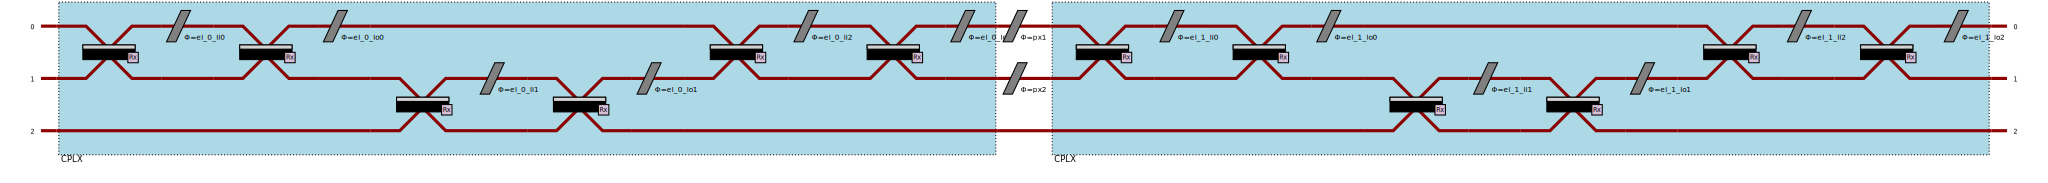

In [7]:
# Define the basic interferometer
circuit = ml.CircuitBuilder(n_modes=3)
circuit.add_entangling_layer()
circuit.add_angle_encoding([0, 1])
circuit.add_entangling_layer()

pcvl.pdisplay(circuit.to_pcvl_circuit(),recursive=True)

In [8]:
#Non noisy layer
qlayer = ml.QuantumLayer(
    input_size=2,
    builder=circuit,
    n_photons=1,
    measurement_strategy=ml.MeasurementStrategy.probs(
        computation_space=ml.ComputationSpace.UNBUNCHED,
    ),
)


# Noisy layer
## Option 1 pass the noise to a perceval experiment and then to the layer
experiment=pcvl.Experiment(
    m_circuit=circuit.to_pcvl_circuit(),
   noise=pcvl.NoiseModel(
       indistinguishability=0.8636,
       transmittance=0.0244,g2=0.01955
       )
    )
noisy_qlayer = ml.QuantumLayer(
    input_size=2,
    experiment=experiment,
    n_photons=1,
    measurement_strategy=ml.MeasurementStrategy.probs(
        computation_space=ml.ComputationSpace.UNBUNCHED,
    ),
    input_parameters=["px"],
    trainable_parameters=["el"],
)
## Option 2 pass the noise to the noise argument
noisy_qlayer = ml.QuantumLayer(
    input_size=2,
    builder=circuit,
    n_photons=1,
    measurement_strategy=ml.MeasurementStrategy.probs(
        computation_space=ml.ComputationSpace.UNBUNCHED,
    ),
    noise=pcvl.NoiseModel(
        indistinguishability=0.8636,
        transmittance=0.0244,
        g2=0.01955
    )
)

#Run the layers
non_noisy_output=qlayer(torch.tensor([0.5,1.1]))
noisy_output=noisy_qlayer(torch.tensor([0.5,1.1]))

print(f"The perfect simulation has output:")
for key, prob in zip(qlayer.output_keys, non_noisy_output.flatten()):
        print(f"Output probability of state {key} is {prob}")
print()

print(f"The noisy simulation has output:")
for key, prob in zip(noisy_qlayer.output_keys, noisy_output.flatten()):
        print(f"Output probability of state {key} is {prob}")

The perfect simulation has output:
Output probability of state (1, 0, 0) is 0.31360045075416565
Output probability of state (0, 1, 0) is 0.31970536708831787
Output probability of state (0, 0, 1) is 0.3666941523551941

The noisy simulation has output:
Output probability of state (1, 0, 0) is 0.01008016336709261
Output probability of state (0, 0, 0) is 0.9753627181053162
Output probability of state (0, 1, 0) is 0.014294881373643875
Output probability of state (0, 0, 1) is 0.0002563434245530516
Output probability of state (2, 0, 0) is 9.940723657564376e-07
Output probability of state (1, 1, 0) is 2.819427663780516e-06
Output probability of state (1, 0, 1) is 5.0559478381728695e-08
Output probability of state (0, 2, 0) is 1.9991432509414153e-06
Output probability of state (0, 1, 1) is 7.169940374751604e-08
Output probability of state (0, 0, 2) is 6.428759191656752e-10


/Users/lfvigneux/Documents/GitHub/merlin/merlin/utils/deprecations.py:545: UserWarning: Noisy simulations with source noise currently use ComputationSpace.FOCK. Other computation spaces are not yet supported for noise models. pcvl.detectors can be used to use custom post-selection.
  return func(*f_args, **kwargs)


We observe that the outputs are very different. So training locally your quantum models with noise models that are similar to the actual QPU will be useful to get meaningful QPU results.

### 1.6 New ``EncodingSpace`` Object

`EncodingSpace` describes how the last dimension of an amplitude tensor maps into MerLin's canonical Fock basis. It makes logical amplitude inputs explicit and removes the need to manually enumerate Fock states for common encodings.

Supported encodings include:

- `EncodingSpace.FOCK` for amplitudes already in full Fock order;
- `EncodingSpace.UNBUNCHED` for collision-free photonic states;
- `EncodingSpace.DUAL_RAIL` for qubit-like binary logical states;
- partitioned encodings through `EncodingSpace(modes_per_photon=[...])`;
- QLOQ-style grouped encodings through `EncodingSpace.qloq(...)`.

`StateVector.from_tensor(..., encoding=...)` validates the logical tensor, embeds it into Fock order, and returns a `StateVector` that can be passed to `QuantumLayer.forward()`.

For more details, consult the [API documentation](../../api_reference/api/merlin.core.encoding_space.rst)

Here is an example of the usage for a tensor in the unbunched space of 2 photons and 4 modes.

In [9]:
#1. Define the tensor in the logical space
#There is 6 basis states in the unbunched space of 2 photons and 4 modes
unbunched_tensor=torch.arange(1,7,dtype=torch.float64)
unbunched_tensor=unbunched_tensor/torch.norm(unbunched_tensor)
print(unbunched_tensor)

#2. Encode it into a state vector with the EncodingSpace object
encoded_state=StateVector.from_tensor(tensor=unbunched_tensor,encoding=ml.EncodingSpace.UNBUNCHED,n_modes=4,n_photons=2)
print(encoded_state.tensor)

tensor([0.1048, 0.2097, 0.3145, 0.4193, 0.5241, 0.6290], dtype=torch.float64)
tensor([0.0000+0.j, 0.1048+0.j, 0.2097+0.j, 0.3145+0.j, 0.0000+0.j, 0.4193+0.j, 0.5241+0.j,
        0.0000+0.j, 0.6290+0.j, 0.0000+0.j])


### 1.7 MerlinProcessor Local Processor Support


`MerlinProcessor` now accepts Perceval `AProcessor` objects through the keyword-only `processor=` argument.

This means local Perceval processors can be used from the same MerLin execution interface as remote processors and sessions. Local processors use a local backend route. `RemoteProcessor` instances passed through `processor=` are normalized to the remote backend route. The older `remote_processor=` argument still works as a deprecated compatibility path.

This is useful when users want to evaluate MerLin models on local Perceval backends, including local noisy or sampling backends, without leaving the MerLin model execution workflow.

Check out the corresponding deprecation section (3.1) explaining the migration.

### 1.8 Reclarified kernel contract

The kernel has been restructured to be built directly on ``QuantumLayer``s instead of a completely different backbone. That way, the updates and changes of the ``QuantumLayer`` are directly applied to the kernels. Here are the new contracts.

- `FeatureMap` – a descriptor that stores
	 the photonic circuit and its parameter layout. It accepts:

	 - a `pcvl.Circuit` (manual construction),
	 - a `CircuitBuilder` (declarative), or
	 - a `pcvl.Experiment` (unitary circuit + measurement semantics).


- `FidelityKernel` – validates the feature map, builds the intrinsic ``QuantumLayer``, normalizes public inputs, and delegates kernel-matrix construction to the backend.


The compatibility methods such as `KernelCircuitBuilder`, `FidelityKernel.simple(...)` and simple-factory compatibility arguments are deprecated. Indeed, you can now use the regular ``CircuitBuilder`` to build your feature map as `FeatureMap` is now defined as the main contract to define the circuit. Therefore, circuits are defined in ``FeatureMap`` and then, this is passed to the ``FidelityKernel``.

As you can now build a circuit using the builder in the `FeatureMap`, it is not necessary to use the ``KernelCircuitBuilder``!

### 1.9 StateVector and Sparse State Workflows

`StateVector` and probability-distribution objects have improved support for sparse tensors and logical-to-Fock mappings. This helps amplitude-input workflows stay memory-aware, especially when the logical state is much smaller than the full Fock basis.

## 2. Breaking Changes
Here are features that are now completely removed from v.0.4.

### 2.1 The ``no_bunching`` Flag Is Now Removed

The ``no_bunching`` flag used in version 0.1 and 0.2 in many functions (QuantumLayer and kernels definitions) was deprecated since version 0.3.0 and is now removed. The new way of deciding to use the unbunched or full Fock computation space is with the ``ComputationSpace`` object in the ``MeasurementStrategy``. Here we present the two ways to define a ``QuantumLayer`` with the equivalent of settng the ``no_bunching`` flag to True or False.

In [10]:
# Define the basic interferometer
circuit = ml.CircuitBuilder(n_modes=3)
circuit.add_entangling_layer()
circuit.add_angle_encoding([0, 1])
circuit.add_entangling_layer()

Old flag, breaking change

In [11]:
# # Unbunched space
# qlayer=ml.QuantumLayer(
#     input_size=2,
#     builder=circuit,
#     n_photons=1,
#     no_bunching=True
#     )

# # Full Fock space
# qlayer=ml.QuantumLayer(
#     input_size=2,
#     builder=circuit,
#     n_photons=1,
#     no_bunching=False
#     )

Equivalents of the flag

In [12]:
# Equivalent of no_bunching=True
qlayer = ml.QuantumLayer(
    input_size=2,
    builder=circuit,
    n_photons=1,
    measurement_strategy=ml.MeasurementStrategy.probs(
        computation_space=ml.ComputationSpace.UNBUNCHED,
    ),
)
print(qlayer.computation_space)

## Or, because the unbunched space is applied by default
qlayer = ml.QuantumLayer(
    input_size=2,
    builder=circuit,
    n_photons=1,
)
print(qlayer.computation_space)

# Equivalent of no_bunching=False
qlayer = ml.QuantumLayer(
    input_size=2,
    builder=circuit,
    n_photons=1,
    measurement_strategy=ml.MeasurementStrategy.probs(
        computation_space=ml.ComputationSpace.FOCK,
    ),
)
print(qlayer.computation_space)

ComputationSpace.UNBUNCHED
ComputationSpace.UNBUNCHED
ComputationSpace.FOCK


### 2.2 Constructor ``computation_space`` Is Removed

The legacy ``computation_space`` in the constrictor of the ``QuantumLayer`` is now removed. It was deprecated in v.0.3 and is now removed in v.0.4.

Use explicit computation-space configuration instead:

In [13]:
# Define the basic interferometer
circuit = ml.CircuitBuilder(n_modes=3)
circuit.add_entangling_layer()
circuit.add_angle_encoding([0, 1])
circuit.add_entangling_layer()

Old flag, breaking change

In [14]:
# # Unbunched space
# qlayer=ml.QuantumLayer(
#     input_size=2,
#     builder=circuit,
#     n_photons=1,
#     computation_space=ml.ComputationSpace.UNBUNCHED
#     )

# # Full Fock space
# qlayer=ml.QuantumLayer(
#     input_size=2,
#     builder=circuit,
#     n_photons=1,
#     computation_space=ml.ComputationSpace.FOCK,
#     )

Equivalents of the flag

In [15]:
# Equivalent of computation_space=ml.ComputationSpace.UNBUNCHED
qlayer = ml.QuantumLayer(
    input_size=2,
    builder=circuit,
    n_photons=1,
    measurement_strategy=ml.MeasurementStrategy.probs(
        computation_space=ml.ComputationSpace.UNBUNCHED,
    ),
)
print(qlayer.computation_space)

# Equivalent of computation_space=ml.ComputationSpace.FOCK
qlayer = ml.QuantumLayer(
    input_size=2,
    builder=circuit,
    n_photons=1,
    measurement_strategy=ml.MeasurementStrategy.probs(
        computation_space=ml.ComputationSpace.FOCK,
    ),
)
print(qlayer.computation_space)

ComputationSpace.UNBUNCHED
ComputationSpace.FOCK


### 2.3 Legacy MeasurementStrategy Access Is Removed

Legacy enum-style measurement access such as MeasurementStrategy.PROBABILITIES, MeasurementStrategy.MODE_EXPECTATIONS, and MeasurementStrategy.AMPLITUDES now fails with a migration error. Passing measurement strategies as strings, such as "PROBABILITIES", is also no longer supported.

The accepted way is now to use ``MeasurementStrategy`` factory methods:

- ``MeasurementStrategy.probs(...)``
- ``MeasurementStrategy.mode_expectations(...)``
- ``MeasurementStrategy.amplitudes(...)``
- ``MeasurementStrategy.partial(...)``

Here are the suggested replacements

- ``MeasurementStrategy.PROBABILITIES``
    - ``MeasurementStrategy.probs(computation_space=...)``
- ``MeasurementStrategy.MODE_EXPECTATIONS``
    - ``MeasurementStrategy.mode_expectations(computation_space=...)``
- ``MeasurementStrategy.AMPLITUDES``
    - ``MeasurementStrategy.amplitudes(computation_space=...)``
- ``MeasurementStrategy.NONE``
    - ``MeasurementStrategy.amplitudes(computation_space=...)``
- ``"PROBABILITIES"`` (string)
    - ``MeasurementStrategy.probs(computation_space=...)``

We will present the migration for the probabilities strategy.

In [16]:
# Define the basic interferometer
circuit = ml.CircuitBuilder(n_modes=3)
circuit.add_entangling_layer()
circuit.add_angle_encoding([0, 1])
circuit.add_entangling_layer()

Old accesses, breaking change

In [17]:
# # Enum-style access
# qlayer=ml.QuantumLayer(
#     input_size=2,
#     builder=circuit,
#     n_photons=1,
#     measurement_strategy=ml.MeasurementStrategy.PROBABILITIES
#     )

# # String access
# qlayer=ml.QuantumLayer(
#     input_size=2,
#     builder=circuit,
#     n_photons=1,
#     measurement_strategy="PROBABILITIES"
#     )

Equivalents of the flag

In [ ]:
qlayer = ml.QuantumLayer(
    input_size=2,
    builder=circuit,
    n_photons=1,
    measurement_strategy=ml.MeasurementStrategy.probs(),
)
print(qlayer.measurement_strategy)

MeasurementStrategy(type=<MeasurementKind.PROBABILITIES: 'PROBABILITIES'>, measured_modes=(), computation_space=<ComputationSpace.UNBUNCHED: 'unbunched'>, grouping=None, occupancy_readout=False)


### 2.4 Constructor Amplitude Encoding Removed

``QuantumLayer(..., amplitude_encoding=True)`` is no longer accepted.

Amplitude inputs should now be passed to ``QuantumLayer.forward()`` as either a ``StateVector`` or a complex tensor.

Let's present these alternatives.

In [19]:
# Define the basic interferometer
circuit = ml.CircuitBuilder(n_modes=3)
circuit.add_entangling_layer()

Old flag, breaking change

In [ ]:
# qlayer=ml.QuantumLayer(
#     input_size=2,
#     builder=circuit,
#     n_photons=1,
#     amplitude_encoding=True
#     )

Equivalents of the flag

In [21]:
qlayer=ml.QuantumLayer(
    builder=circuit,
    n_photons=1,
    )

# Option 1: StateVector input
input_state = StateVector.from_tensor(
    tensor=torch.rand(1, 3),
    n_modes=3,
    n_photons=1,
    encoding=ml.EncodingSpace.FOCK,
)
qlayer(input_state)
# Option 2: complex tensor
input_state = torch.rand(1, qlayer.output_size, dtype=torch.complex64)

qlayer(input_state)

tensor([[0.0068, 0.6490, 0.3442]], grad_fn=<ViewBackward0>)

### 2.5 Tensor Constructor ``input_state`` Removed

Passing a raw ``torch.Tensor`` as constructor input_state is no longer accepted. If a state object is needed at construction time, build it explicitly with ``StateVector.from_tensor(...)``.

Here is exactly how to migrate from the previous API.

In [22]:
# Define the basic interferometer
circuit = ml.CircuitBuilder(n_modes=3)
circuit.add_entangling_layer()
circuit.add_angle_encoding([0, 1])
circuit.add_entangling_layer()

Old flag, breaking change

In [23]:
# # Tensor input state
# amplitudes=torch.rand(2)
# qlayer=ml.QuantumLayer(
#     input_size=3,
#     builder=circuit,
#     n_photons=1,
#     input_state=amplitudes
#     )

Equivalents of the flag

In [24]:
# StateVector input
amplitudes=torch.rand(3)
input_state=StateVector.from_tensor(
      amplitudes,
      n_modes=3,
      n_photons=1,
      encoding=ml.EncodingSpace.UNBUNCHED,
  )

qlayer=ml.QuantumLayer(
    input_size=2,
    builder=circuit,n_photons=1,
    input_state=input_state
    )

## 3. Deprecations

Two new deprecations are effective since version v.0.4.

### 3.1 ``remote_processor`` Argument of the ``MerlinProcessor`` Is Deprecated

The name of the previous ``remote_processor`` argument is now simply ``processor`` where you pass the same Perceval processor.

In [25]:
#Deprecated
# local_processor = pcvl.Processor("SLOS")
# proc = ml.MerlinProcessor(remote_processor=local_processor)

#New method
local_processor = pcvl.Processor("SLOS")
proc = ml.MerlinProcessor(processor=local_processor)

### 3.2 Kernel Compatibility Helpers Are Deprecated

As it was identifed in the section 1.8, kernel compatibility helpers such as ``KernelCircuitBuilder``, ``FidelityKernel.simple(...)``, and related simple-factory compatibility arguments are deprecated and kept only for transition.

## 4. Compatibility and Maintenance

MerLin 0.4 updates the dependency floor to ``perceval-quandela>=1.2.1`` and allows newer ``PyTorch`` versions up to ``torch<=2.12.0``.

The test suite has been expanded substantially around noisy SLOS, g2 behavior, encoding spaces, state-vector inputs, deprecation removals, ``MerlinProcessor`` local execution, photonic generators, QCNNs, and QORC reservoir workflows.

### Note for the user: 

To move your models or ``QuantumLayer``s between cpu and gpu, please use the ``.to(...)`` method instead of ``.cuda()`` or ``.cpu()``. Only the ``.to(...)`` method has been optimized for a safe moving between device.